# Analiza wyjaśnialności modelu XGBoost po tuningu
Ponizszy rozdział przedstawia analizę SHAP oraz LIME, wykonaną na najlepszym modelu z poprzedniego rozdziału.


In [32]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning, message="IProgress not found.*")


In [33]:
model_path = Path('artifacts/models/XGBoost_tuned.joblib')
if not model_path.exists():
    raise FileNotFoundError(f'Nie znaleziono modelu: {model_path}')

data_candidates = [
    Path('data/final_data.parquet'),
    Path('data/clean_data.parquet'),
]

data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('Nie znaleziono pliku data/final_data.parquet ani data/clean_data.parquet')

target_col = 'tran_cena_brutto'
top10_features = [
    'lok_pow_uzyt',
    'Ulica',
    'coord_y',
    'coord_x',
    'nier_pow_gruntu',
    'dzielnica',
    'tran_rodzaj_trans',
    'tran_rodzaj_rynku',
    'lok_liczba_izb',
    'tran_sprzedajacy',
]

pipe = joblib.load(model_path)
df = pd.read_parquet(data_path)

required_cols = top10_features + [target_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Brakuje kolumn w danych: {missing_cols}')

analysis_df = df[required_cols].dropna().copy()
X = analysis_df[top10_features]
y = analysis_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

# print('Model:', model_path)
# print('Dane :', data_path)
# print('X_train:', X_train.shape, '| X_test:', X_test.shape)


In [34]:
preprocessor = pipe.named_steps['preprocessor']
model = pipe.named_steps['model']

X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_train_trans, 'toarray'):
    X_train_trans = X_train_trans.toarray()
if hasattr(X_test_trans, 'toarray'):
    X_test_trans = X_test_trans.toarray()

# print('Transform shape train:', X_train_trans.shape)
# print('Transform shape test :', X_test_trans.shape)
# print('Liczba cech po preprocessingu:', len(feature_names))


## SHAP - globalna wyjasnialosc
Poniższy segment przedstawia analizę SHAP w kontekście globalnym

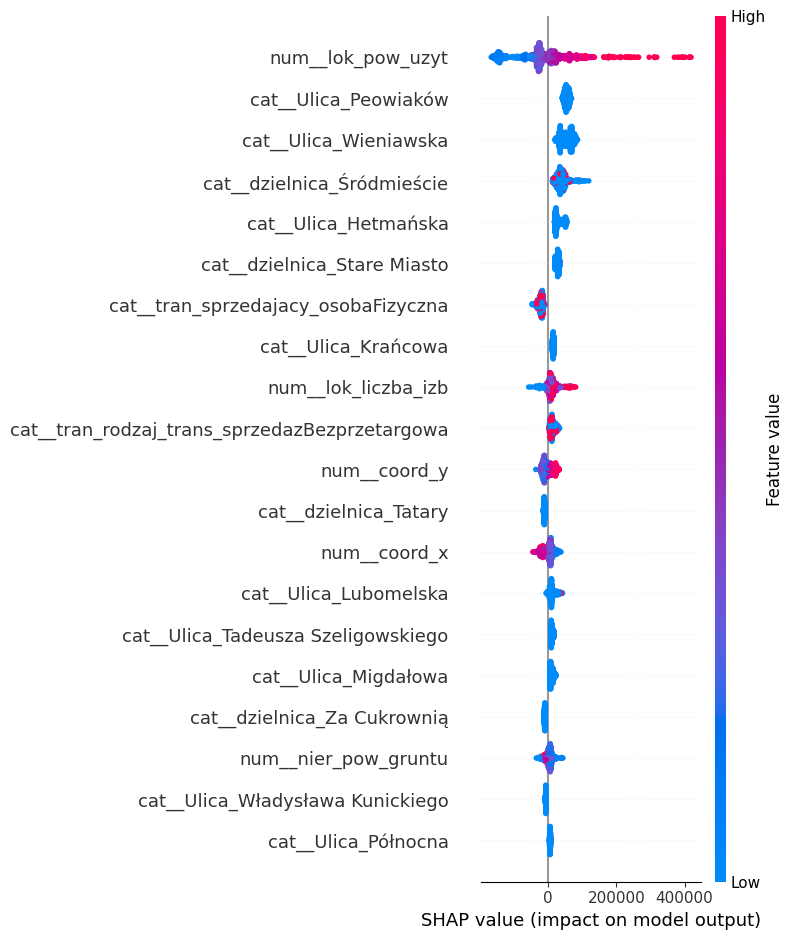

,feature,mean_abs_shap
0,num__lok_pow_uzyt,67643.429688
1,cat__Ulica_Peowiaków,54131.847656
2,cat__Ulica_Wieniawska,53517.445312
3,cat__dzielnica_Śródmieście,39494.070312
4,cat__Ulica_Hetmańska,29625.388672
5,cat__dzielnica_Stare Miasto,27743.382812
6,cat__tran_sprzedajacy_osobaFizyczna,21297.722656
7,cat__Ulica_Krańcowa,14376.721680
8,num__lok_liczba_izb,13247.250977
9,cat__tran_rodzaj_trans_sprzedazBezprzetargowa,13157.400391


In [35]:
rng = np.random.RandomState(42)
sample_size = min(1000, X_test_trans.shape[0])
sample_idx = rng.choice(X_test_trans.shape[0], size=sample_size, replace=False)
X_shap = X_test_trans[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(shap_importance_df.head(20))


Na wykresie widać, że największy globalny wpływ ma num__lok_pow_uzyt – wysokie wartości tej cechy (kolor czerwony) najczęściej przesuwają predykcję w prawo, czyli zwiększają prognozowaną cenę. Wysoko znajdują się też cechy lokalizacyjne (ulice i dzielnice), co potwierdza, że lokalizacja jest kluczowym czynnikiem modelu. 

W powyższej tabeli przedstawiono średnią bezwzględność wartość SHAP dla najważniejszych 20 cech. Wyniki pokrywają się z wnioskami wyciągniętymi z wykresu.

## SHAP - lokalna wyjasnialosc jednej predykcji
Poniższy segment przedstawia przykładową wyjaśnialność jednej obserwacji ze zbioru testowego, w tym przypadku taką o id=15

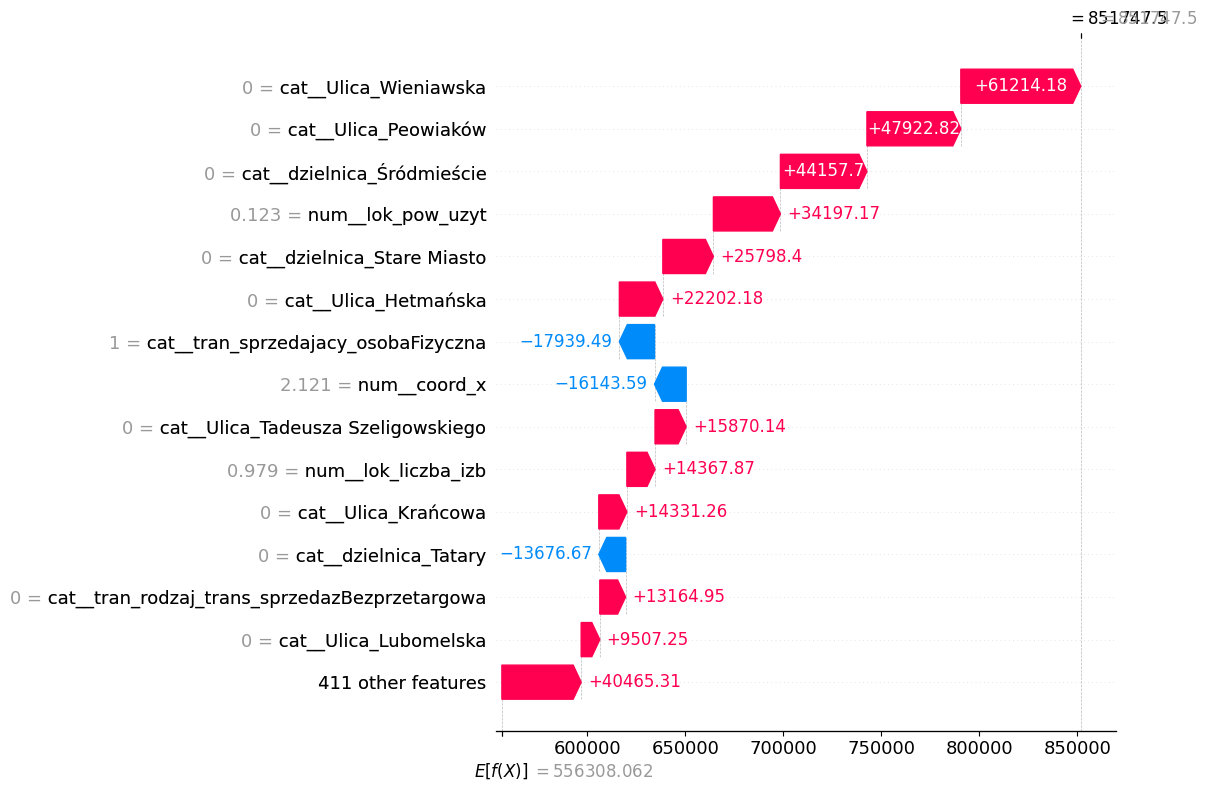

In [36]:
# Shared index for local explainability comparison (SHAP vs LIME)
target_idx = 15

base_value = explainer.expected_value
if isinstance(base_value, np.ndarray):
    base_value = float(np.ravel(base_value)[0])

# Use the same exact row from X_test_trans for local SHAP
target_row = X_test_trans[target_idx:target_idx + 1]
target_shap_values = np.asarray(explainer.shap_values(target_row)).reshape(-1)

single_exp = shap.Explanation(
    values=target_shap_values,
    base_values=base_value,
    data=X_test_trans[target_idx],
    feature_names=feature_names,
)

shap.plots.waterfall(single_exp, max_display=15)


Czynniki zwiększające predykcję ceny (SHAP > 0):
- cat__Ulica_Wieniawska +61 214,18
- cat__Ulica_Peowiaków +47 922,82
- cat__dzielnica_Śródmieście +44 157,70
- num__lok_pow_uzyt +34 197,17
- cat__dzielnica_Stare Miasto +25 798,40
- cat__Ulica_Hetmańska +22 202,18
- cat__Ulica_Tadeusza Szeligowskiego +15 870,14
- num__lok_liczba_izb +14 367,87
- cat__Ulica_Krańcowa +14 331,26
- cat__tran_rodzaj_trans_sprzedazBezprzetargowa +13 164,95
- cat__Ulica_Lubomelska +9 507,25
- 411 other features (łączny wpływ) +40 465,31

Czynniki obniżające predykcję ceny (SHAP < 0):
- cat__tran_sprzedajacy_osobaFizyczna −17 939,49
- num__coord_x −16 143,50
- cat__dzielnica_Tatary −13 676,67


## LIME - lokalna wyjasnialosc jednej predykcji
Na poniższym wykresie przedstaiono analizę LIME dla obserwacji ze zbioru testowego o id=15, tak samo jak w poprzednim segmencie.

,feature,weight
0,num__lok_pow_uzyt > 0.11,361054.577071
1,cat__Ulica_Widok <= 0.00,96153.894666
2,cat__Ulica_Sebastiana Klonowica <= 0.00,84249.679638
3,cat__Ulica_Kolorowa <= 0.00,-83457.891573
4,cat__Ulica_Pana Wołodyjowskiego <= 0.00,81136.641915
5,cat__Ulica_Leona Wyczółkowskiego <= 0.00,-79408.500090
6,cat__Ulica_Słoneczna <= 0.00,-69515.148637
7,cat__Ulica_Bukowa <= 0.00,60270.461344
8,cat__Ulica_Tadeusza Grodzickiego <= 0.00,-50408.978968
9,cat__Ulica_Żołnierzy Niepodległej <= 0.00,47541.684190


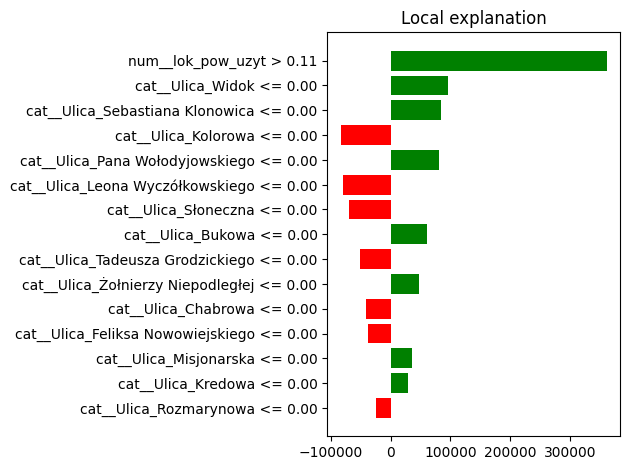

In [37]:
lime_train_size = min(2000, X_train_trans.shape[0])
lime_train_idx = rng.choice(X_train_trans.shape[0], size=lime_train_size, replace=False)
lime_train = X_train_trans[lime_train_idx]

lime_explainer = LimeTabularExplainer(
    training_data=lime_train,
    feature_names=list(feature_names),
    mode='regression',
    discretize_continuous=True,
    random_state=42,
)

def predict_transformed(x):
    return model.predict(x)

# Reuse SHAP local index if available to compare the same observation
if 'target_idx' not in globals():
    target_idx = 15

lime_instance_idx = target_idx
lime_instance = X_test_trans[lime_instance_idx]
lime_exp = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=predict_transformed,
    num_features=15,
)

lime_df = pd.DataFrame(lime_exp.as_list(), columns=['feature', 'weight'])
display(lime_df)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()


Czynniki zwiększające predykcję (weight > 0):
- num__lok_pow_uzyt > 0.11 +361 054,58
- cat__Ulica_Widok <= 0.00 +96 153,89
- cat__Ulica_Sebastiana Klonowica <= 0.00 +84 249,68
- cat__Ulica_Pana Wołodyjowskiego <= 0.00 +81 136,64
- cat__Ulica_Bukowa <= 0.00 +60 270,46
- cat__Ulica_Żołnierzy Niepodległej <= 0.00 +47 541,68
- cat__Ulica_Misjonarska <= 0.00 +36 132,70
- cat__Ulica_Kredowa <= 0.00 +29 596,19


Czynniki obniżające predykcję (weight < 0):
- cat__Ulica_Kolorowa <= 0.00 −83 457,89
- cat__Ulica_Leona Wyczółkowskiego <= 0.00 −79 408,50
- cat__Ulica_Słoneczna <= 0.00 −69 515,15
- cat__Ulica_Tadeusza Grodzickiego <= 0.00 −50 408,98
- cat__Ulica_Chabrowa <= 0.00 −41 685,57
- cat__Ulica_Feliksa Nowowiejskiego <= 0.00 −37 475,57
- cat__Ulica_Rozmarynowa <= 0.00 −24 849,43


## Wnioski dla obserwacji z id=15
- Wspólne dla SHAP i LIME: dodatni wpływ num__lok_pow_uzyt oraz wysoka istotność cech lokalizacyjnych.
- Różnice: inne pojedyncze ulice w top cechach, wynikające z odmiennego sposobu wyznaczania wkładów cech przez obie metody.

In [38]:
out_dir = Path('artifacts/explainability')
out_dir.mkdir(parents=True, exist_ok=True)

local_idx = int(target_idx) if 'target_idx' in globals() else int(lime_instance_idx)

shap_importance_path = out_dir / 'xgboost_tuned_shap_importance.csv'
lime_path = out_dir / f'xgboost_tuned_lime_instance_{local_idx}.csv'
lime_html_path = out_dir / f'xgboost_tuned_lime_instance_{local_idx}.html'

shap_importance_df.to_csv(shap_importance_path, index=False)
lime_df.to_csv(lime_path, index=False)
lime_exp.save_to_file(str(lime_html_path))

# print('Zapisano:')
# print('-', shap_importance_path)
# print('-', lime_path)
# print('-', lime_html_path)
